In [225]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [226]:
cap=pd.read_csv(r"C:\Users\Viplav Gupta\Downloads\cap-production-data.csv")

In [227]:
cap.head()

,Date & Time,Production per hour,Total Production
0,27/01/2024 17:11:44,77,77
1,27/01/2024 18:11:44,52,129
2,27/01/2024 19:11:44,62,191
3,27/01/2024 20:11:44,47,238
4,27/01/2024 21:11:44,35,273


In [228]:
cap.describe()

,Production per hour
count,499.000000
mean,65.917836
std,278.952637
min,-63.000000
25%,16.500000
50%,46.000000
75%,75.000000
max,5879.000000


In [229]:
cap.isnull()

,Date & Time,Production per hour,Total Production
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
494,False,False,False
495,False,False,False
496,False,False,False
497,False,False,False


In [230]:
cap.isnull().sum()

Date & Time            0
Production per hour    0
Total Production       0
dtype: int64

In [231]:
print(cap["Production per hour"].describe)

<bound method NDFrame.describe of 0      77
1      52
2      62
3      47
4      35
       ..
494    19
495    21
496    94
497    47
498    71
Name: Production per hour, Length: 499, dtype: int64>


In [232]:
cap['Date & Time'] = pd.to_datetime(cap['Date & Time'], errors='coerce')

C:\Users\Viplav Gupta\AppData\Local\Temp\ipykernel_4448\2828767740.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cap['Date & Time'] = pd.to_datetime(cap['Date & Time'], errors='coerce')


In [233]:
print(cap['Date & Time'].dtype)

datetime64[ns]


In [234]:
a=cap["Production per hour"].quantile(0.25)
print(a)
b=cap["Production per hour"].quantile(0.75)
print(b)
InterQR=b-a
print(InterQR)

16.5
75.0
58.5


In [235]:
b=cap["Production per hour"].quantile(0.75)
print(b)

75.0


In [236]:
print(InterQR)

58.5


In [237]:
l=a-1.5*InterQR
u=a+1.5*InterQR

In [238]:
print(l,u)

-71.25 104.25


In [239]:
outlier1=cap[(cap["Production per hour"]<l) | (cap["Production per hour"]>u)]

In [240]:
print(outlier1)

            Date & Time  Production per hour Total Production
21  2024-01-28 14:11:44                 1002            1,900
62  2024-01-30 07:11:44                 5879            9,604
151 2024-02-03 00:11:44                  526           13,054
184 2024-02-04 09:11:44                 1532           15,969
408 2024-02-13 17:11:44                  666           27,859
463 2024-02-16 00:11:44                  852           31,199


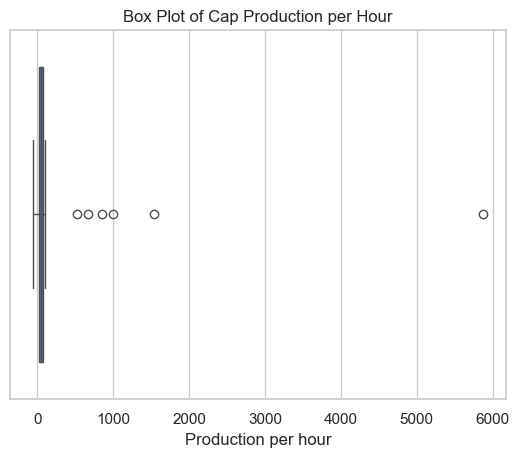

'"sns.boxplot(y=cap[\'Production per hour\'])\nplt.title("Box Plot of Cap Production per Hour")\nplt.figure(figsize=(10,2))'

In [241]:
sns.boxplot(x=cap['Production per hour'])
plt.title("Box Plot of Cap Production per Hour")
plt.show()

""""sns.boxplot(y=cap['Production per hour'])
plt.title("Box Plot of Cap Production per Hour")
plt.figure(figsize=(10,2))"""


In [242]:
negative_production = cap[(cap['Production per hour'] < 0)]
negative_production

,Date & Time,Production per hour,Total Production
17,2024-01-28 10:11:44,-2,758
45,2024-01-29 14:11:44,-60,"2,865"
122,2024-02-01 19:11:44,-34,"11,801"
175,2024-02-04 00:11:44,-9,"14,116"
317,2024-02-09 22:11:44,-63,"22,437"


In [243]:
outlier=[outlier1]+[negative_production]
outlier

[            Date & Time  Production per hour Total Production
 21  2024-01-28 14:11:44                 1002            1,900
 62  2024-01-30 07:11:44                 5879            9,604
 151 2024-02-03 00:11:44                  526           13,054
 184 2024-02-04 09:11:44                 1532           15,969
 408 2024-02-13 17:11:44                  666           27,859
 463 2024-02-16 00:11:44                  852           31,199,
             Date & Time  Production per hour Total Production
 17  2024-01-28 10:11:44                   -2              758
 45  2024-01-29 14:11:44                  -60            2,865
 122 2024-02-01 19:11:44                  -34           11,801
 175 2024-02-04 00:11:44                   -9           14,116
 317 2024-02-09 22:11:44                  -63           22,437]

In [244]:
median_value = cap['Production per hour'].median()

In [245]:
median_value

46.0

In [246]:
print(type(outlier1))

<class 'pandas.core.frame.DataFrame'>


In [247]:
outlier_values = outlier1['Production per hour'].tolist()

In [248]:
print(type(outlier1))

<class 'pandas.core.frame.DataFrame'>


In [249]:
median_value = cap['Production per hour'].median()
cap['Production per hour'] = cap['Production per hour'].apply(lambda x: median_value if x in outlier_values else x)

In [250]:
remaining_outliers = cap[cap['Production per hour'].isin(outlier_values)]
print("Remaining outliers after replacement:")
print(remaining_outliers)

Remaining outliers after replacement:
Empty DataFrame
Columns: [Date & Time, Production per hour, Total Production]
Index: []


In [251]:
cap['hour'] = cap['Date & Time'].dt.hour
cap['day'] = cap['Date & Time'].dt.day
cap['weekday'] = cap['Date & Time'].dt.weekday
cap['month'] = cap['Date & Time'].dt.month


In [252]:
cap.head()

,Date & Time,Production per hour,Total Production,hour,day,weekday,month
0,2024-01-27 17:11:44,77.0,77,17,27,5,1
1,2024-01-27 18:11:44,52.0,129,18,27,5,1
2,2024-01-27 19:11:44,62.0,191,19,27,5,1
3,2024-01-27 20:11:44,47.0,238,20,27,5,1
4,2024-01-27 21:11:44,35.0,273,21,27,5,1


In [253]:
cap.drop(['Date & Time'],axis=1,inplace=True)

In [254]:
cap.reset_index(drop=True, inplace=True)

In [255]:
print("Positive Outliers:\n", outlier1)
print("Negative Outliers:\n", negative_production)


Positive Outliers:
             Date & Time  Production per hour Total Production
21  2024-01-28 14:11:44                 1002            1,900
62  2024-01-30 07:11:44                 5879            9,604
151 2024-02-03 00:11:44                  526           13,054
184 2024-02-04 09:11:44                 1532           15,969
408 2024-02-13 17:11:44                  666           27,859
463 2024-02-16 00:11:44                  852           31,199
Negative Outliers:
             Date & Time  Production per hour Total Production
17  2024-01-28 10:11:44                   -2              758
45  2024-01-29 14:11:44                  -60            2,865
122 2024-02-01 19:11:44                  -34           11,801
175 2024-02-04 00:11:44                   -9           14,116
317 2024-02-09 22:11:44                  -63           22,437


In [256]:
all_outliers = pd.concat([outlier1, negative_production])

In [257]:
outlier_values = all_outliers['Production per hour'].tolist()

In [258]:
median_value = cap['Production per hour'].median()

cap['Production per hour'] = cap['Production per hour'].apply(
    lambda x: median_value if x in outlier_values else x
)

In [259]:
still_present = cap[cap['Production per hour'].isin(outlier_values)]
print("Still present outliers:\n", still_present)

Still present outliers:
 Empty DataFrame
Columns: [Production per hour, Total Production, hour, day, weekday, month]
Index: []


In [260]:
print("Positive Outliers:\n", outlier1)
print("Negative Outliers:\n", negative_production)

Positive Outliers:
             Date & Time  Production per hour Total Production
21  2024-01-28 14:11:44                 1002            1,900
62  2024-01-30 07:11:44                 5879            9,604
151 2024-02-03 00:11:44                  526           13,054
184 2024-02-04 09:11:44                 1532           15,969
408 2024-02-13 17:11:44                  666           27,859
463 2024-02-16 00:11:44                  852           31,199
Negative Outliers:
             Date & Time  Production per hour Total Production
17  2024-01-28 10:11:44                   -2              758
45  2024-01-29 14:11:44                  -60            2,865
122 2024-02-01 19:11:44                  -34           11,801
175 2024-02-04 00:11:44                   -9           14,116
317 2024-02-09 22:11:44                  -63           22,437


In [261]:
print(outlier_values)
print(type(outlier_values))


[1002, 5879, 526, 1532, 666, 852, -2, -60, -34, -9, -63]
<class 'list'>


In [262]:
median_value = cap['Production per hour'].median()
cap.loc[cap['Production per hour'].isin(outlier_values), 'Production per hour'] = median_value

In [263]:
median_value

46.0

In [264]:
cap.head()

,Production per hour,Total Production,hour,day,weekday,month
0,77.0,77,17,27,5,1
1,52.0,129,18,27,5,1
2,62.0,191,19,27,5,1
3,47.0,238,20,27,5,1
4,35.0,273,21,27,5,1


In [265]:
print(cap['Production per hour'].isin(outlier_values).sum())

0


In [266]:
cap['Total Production'] = cap['Production per hour'].cumsum()

In [267]:
from sklearn.model_selection import train_test_split

X = cap[['Production per hour', 'hour', 'day', 'weekday', 'month']]
y = cap['Total Production']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [283]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [284]:

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("RMSE:", rmse)

R² Score: 0.9989330508005224
RMSE: 236.27625225323928


In [270]:
from sklearn.tree import DecisionTreeRegressor

In [271]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Decision Tree R² Score:", r2_score(y_test, y_pred))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Decision Tree R² Score: 0.9998452653756926
Decision Tree RMSE: 89.97916425484291


In [272]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest R² Score:", r2_score(y_test, y_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Random Forest R² Score: 0.9998773843120765
Random Forest RMSE: 80.09791700787234


In [273]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Gradient Boosting R² Score:", r2_score(y_test, y_pred))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Gradient Boosting R² Score: 0.9997948272587067
Gradient Boosting RMSE: 103.61151719228265


In [279]:
cap.head()

,Production per hour,Total Production,hour,day,weekday,month
0,77.0,77.0,17,27,5,1
1,52.0,129.0,18,27,5,1
2,62.0,191.0,19,27,5,1
3,47.0,238.0,20,27,5,1
4,35.0,273.0,21,27,5,1


In [ ]:
pip install xgboost

In [282]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("XGBoost Regressor")
print("R² Score:", r2)
print("RMSE:", rmse)


XGBoost Regressor
R² Score: 0.9997948272587067
RMSE: 76.01059227879861


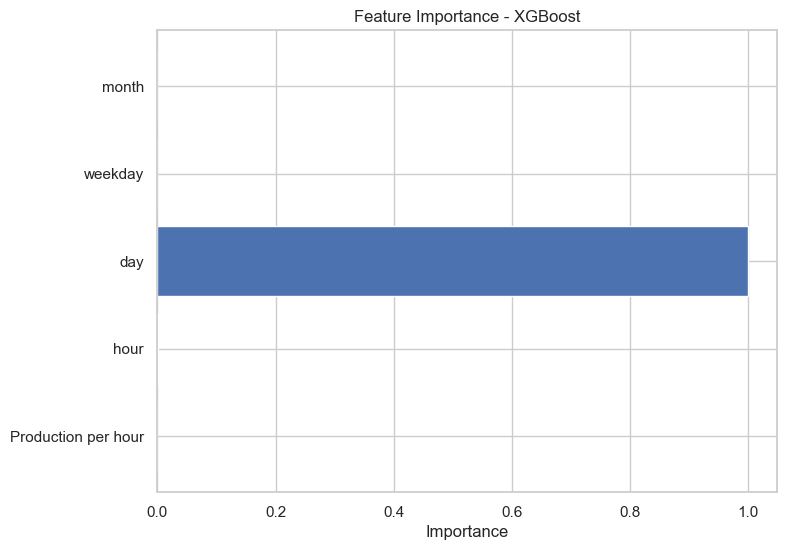

In [276]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
xgb.feature_importances_
plt.barh(X.columns, xgb.feature_importances_)
plt.xlabel("Importance")
plt.title("Feature Importance - XGBoost")
plt.show()


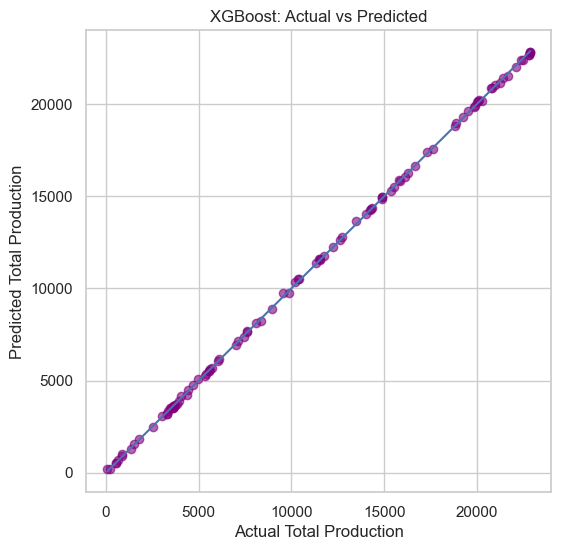

In [302]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='purple')
plt.xlabel("Actual Total Production")
plt.ylabel("Predicted Total Production")
plt.title("XGBoost: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],) 
plt.grid(True)
plt.show()


In [299]:
cap.head()

,Production per hour,Total Production,hour,day,weekday,month
0,77.0,77.0,17,27,5,1
1,52.0,129.0,18,27,5,1
2,62.0,191.0,19,27,5,1
3,47.0,238.0,20,27,5,1
4,35.0,273.0,21,27,5,1


In [300]:
print(cap.columns.tolist())

['Production per hour', 'Total Production', 'hour', 'day', 'weekday', 'month']


In [301]:
average_production_per_hour = cap['Production per hour'].mean()
print("Average Production per Hour:", round(average_production_per_hour, 2))
total_caps_required = 50000
estimated_hours = total_caps_required / average_production_per_hour
print("Estimated Hours to produce 50,000 caps:", round(estimated_hours, 2))

Average Production per Hour: 46.31
Estimated Hours to produce 50,000 caps: 1079.62
